In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Set seed for reproducibility (ensures the same random numbers every time)
np.random.seed(42)

# Simulate 1000 hours of sensor operation
n_samples = 1000

# Generating synthetic sensor data based on Normal Distribution
# 1. Temperature Sensor (Kelvin) - Mean: 200, Std Dev: 50
temperature = np.random.normal(200, 50, n_samples)

# 2. Pressure Sensor (Bar) - Mean: 10, Std Dev: 2
pressure = np.random.normal(10, 2, n_samples)

# 3. Vibration Sensor (mm) - Mean: 0.05, Std Dev: 0.02
vibration = np.random.normal(0.05, 0.02, n_samples)

# Create a DataFrame
df = pd.DataFrame({
    'Sensor_Temp_K': temperature,
    'Sensor_Pressure_Bar': pressure,
    'Sensor_Vibration_mm': vibration
})

# Define Failure Logic (Engineering Rule)
# If Temperature is extremely high OR (Pressure AND Vibration are high) -> Failure (1)
df['Status'] = 0 # Default is 0 (Normal)
df.loc[(df['Sensor_Temp_K'] > 280) | ((df['Sensor_Pressure_Bar'] > 13) & (df['Sensor_Vibration_mm'] > 0.08)), 'Status'] = 1

# Display first 5 rows
print("First 5 rows of the synthetic dataset:")
display(df.head())

# Show class distribution
print("\nSystem Status Distribution (0: Normal, 1: Failure):")
print(df['Status'].value_counts())

First 5 rows of the synthetic dataset:


,Sensor_Temp_K,Sensor_Pressure_Bar,Sensor_Vibration_mm,Status
0,224.835708,12.798711,0.036496,0
1,193.086785,11.849267,0.047110,0
2,232.384427,10.119261,0.034152,0
3,276.151493,8.706126,0.043841,0
4,188.292331,11.396447,0.012128,0



System Status Distribution (0: Normal, 1: Failure):
Status
0    940
1     60
Name: count, dtype: int64


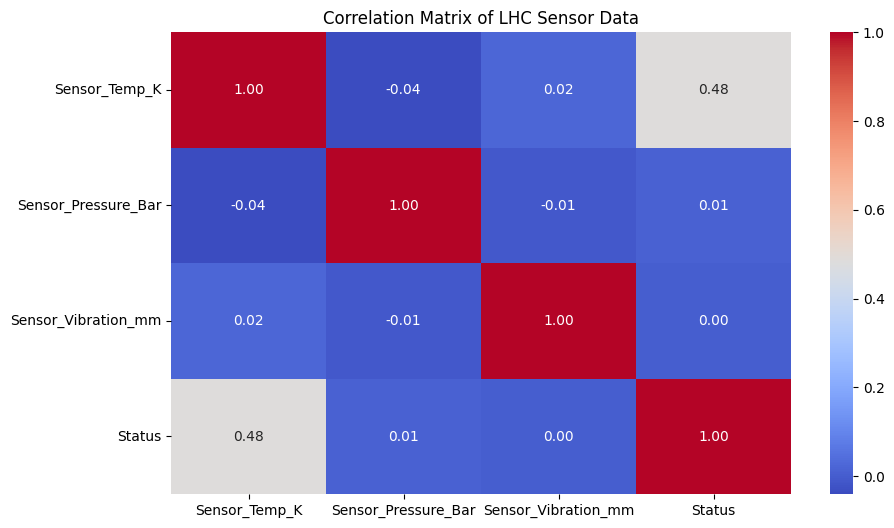

In [3]:
# Visualizing correlations between sensors and system status
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix of LHC Sensor Data")
plt.show()


In [5]:
# Features (X) and Target (y)
X = df.drop('Status', axis=1) # Input data (Sensors)
y = df['Status']              # Output label (Failure or Normal)

# Split data: 80% for Training, 20% for Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize Random Forest Classifier
# n_estimators=100 means we use 100 decision trees
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


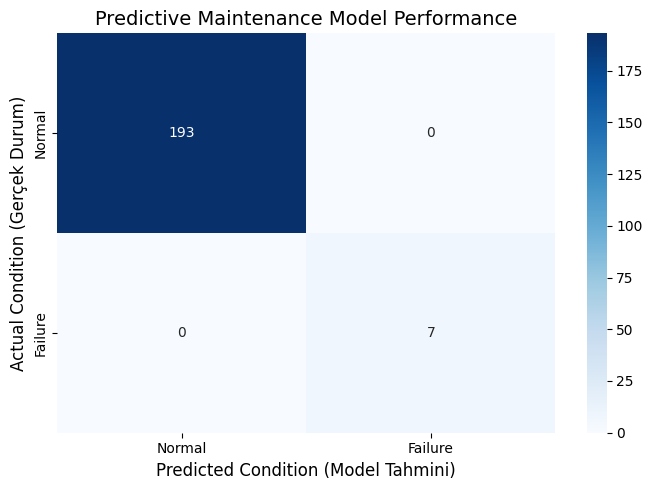

In [8]:
# Daha Profesyonel Confusion Matrix Çizimi
plt.figure(figsize=(7, 5))

# Etiketleri "0-1" yerine kelime yapalım
labels = ['Normal', 'Failure']

# Grafiği çiz
sns.heatmap(confusion_matrix(y_test, predictions),
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

# Eksen ve Başlık İsimleri
plt.xlabel('Predicted Condition (Model Tahmini)', fontsize=12)
plt.ylabel('Actual Condition (Gerçek Durum)', fontsize=12)
plt.title('Predictive Maintenance Model Performance', fontsize=14)

# Kesilmeyi önlemek için sihirli kod:
plt.tight_layout()

plt.show()

/tmp/ipython-input-1373475322.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=features, palette='viridis')


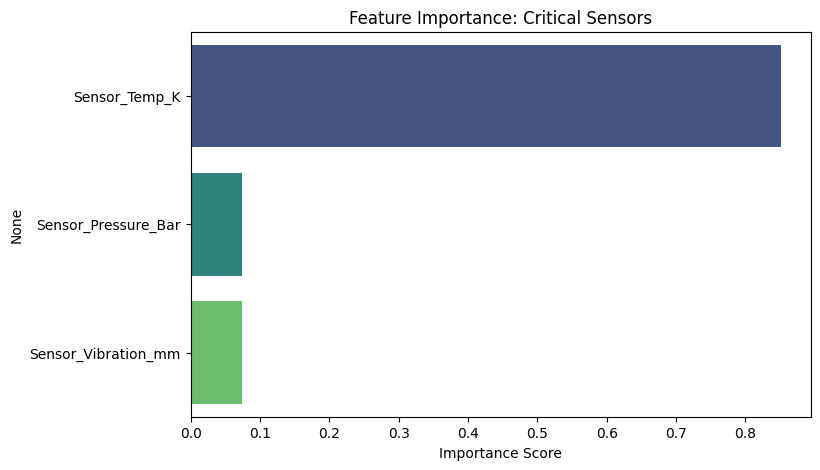

In [7]:
# Analyze which sensor is most critical for failure prediction
importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=features, palette='viridis')
plt.title("Feature Importance: Critical Sensors")
plt.xlabel("Importance Score")
plt.show()